# Hierarchial Audio Classification Using Deep Learning

## Section 0: Imports & Configurations

### Configurations

In [18]:
DATASET = "urbansound8k" # Choose any available dataset from the 'soundata' library
SPECTROGRAM_METHOD = "Mel" # Choose a spectrogram representation: 'STFT', 'Mel', 'MFCCs'

### Import modules

In [25]:
import soundata
import librosa
import numpy as np
import matplotlib.pyplot as plt

INFO: Downloading ['all', 'index']. Index is being stored in P:\DataDocuments\DTU\BSc Project\Hierarchical-Audio-Classification-using-Deep-Learning\bsc-hac\Lib\site-packages\soundata\datasets\indexes, and the rest of files in /tmp\sound_datasets\urbansound8k
INFO: [all] downloading UrbanSound8K.tar.gz
INFO: /tmp\sound_datasets\urbansound8k\UrbanSound8K.tar.gz already exists and will not be downloaded. Rerun with force_overwrite=True to delete this file and force the download.
INFO: /tmp\sound_datasets\urbansound8k\audio already exists. Run with force_overwrite=True to download from scratch
INFO: /tmp\sound_datasets\urbansound8k\FREESOUNDCREDITS.txt already exists. Run with force_overwrite=True to download from scratch
INFO: /tmp\sound_datasets\urbansound8k\metadata already exists. Run with force_overwrite=True to download from scratch
INFO: /tmp\sound_datasets\urbansound8k\UrbanSound8K_README.txt already exists. Run with force_overwrite=True to download from scratch
INFO: [index] downl

({'metadata': {}, 'clips': {}}, {'metadata': {}, 'clips': {}})

### Download Dataset
NOTE: If you already have "DATASET" downloaded and verified, you can skip running this section

In [ ]:
dataset = soundata.initialize(DATASET)
dataset.download()  # download the dataset
dataset.validate()  # validate that all the expected files are there

## Section 1: Preprocessing of data

### Theoretic notes (Draft)

In [ ]:
"""
Waveform:
|------n_fft------|
[Frame 1]
        |------n_fft------|
        [Frame 2]
                |------n_fft------|
                [Frame 3]

- The width of each window = n_fft

- The step between windows = hop_length

- Due to the Newquist Rate = (f_s / 2), the frequency range of the spectrogram will always be
  constrained to the length of the sample width [0Hz, f_s / 2]. 
  The Nyquist rate sets the maximum frequency you can represent.

"""

### Utility functions

In [61]:
def extract_features(y, sr, mode="Mel", n_fft=2048, hop_length=512, n_mels=128, n_mfcc=20):
    """
    y       :  audio time-series, np.ndarray [shape=(..., n)]
    sr      :  sampling rate, number > 0 [scalar]
    mode    :  spectrogram representation, [string]

    returns :
      np.ndarray
      - "STFT": dB magnitude spectrogram shape (n_fft/2+1, t)
      - "Mel": dB mel spectrogram shape (128, t)
      - "MFCCs": MFCC matrix shape (20, t)

    NOTE: 
        n_mels or n_mfcc: controls number of mel bands (i.e., frequency bins after mel filterbank).
    """

    if mode == "STFT":
        S = np.abs(librosa.stft(y))
        return librosa.amplitude_to_db(S, n_fft=n_fft, hop_length=hop_length, ref=np.max)

    elif mode == "Mel":
        S = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=n_fft, hop_length=hop_length, n_mels=n_mels)
        return librosa.power_to_db(S, ref=np.max)

    elif mode == "MFCCs":
        return librosa.feature.mfcc(y=y, sr=sr, n_fft=n_fft, hop_length=hop_length, n_mfcc=n_mfcc)


def plot_spectrogram(S_db, sr, hop_length=512, mode="Mel", cmap="viridis"):
    """
    S_db   : np.ndarray feature matrix in dB (output of extract_features)
    sr     : sample rate
    hop_length: hop length used for STFT/mel (same as used for compute)
    mode   : "STFT" | "Mel" | "MFCCs"
    """
    if mode == "Mel":
        y_axis = "mel"
    elif mode == "STFT":
        y_axis = "linear"
    elif mode == "MFCCs":
        y_axis = "mel"   # any order axis works; MFCC is not freq axis but frame x coef
    else:
        raise ValueError(f"Unsupported mode: {mode}")

    plt.figure(figsize=(8, 4))
    librosa.display.specshow(S_db,
        sr=sr,
        hop_length=hop_length,
        x_axis="time",
        y_axis=y_axis,
        fmin=0,
        fmax= sr / 2, # Nyquist sampling theorem
        cmap=cmap,
    )
    plt.colorbar(format="%+2.0f dB")
    plt.title(f"{mode} spectrogram (dB)")
    plt.tight_layout()
    plt.show()

### (Example) Plotting the spectrogram of Sound Data

In [9]:
example_clip = dataset.choice_clip()  # choose a random example clip
# print(example_clip)  # see the available data

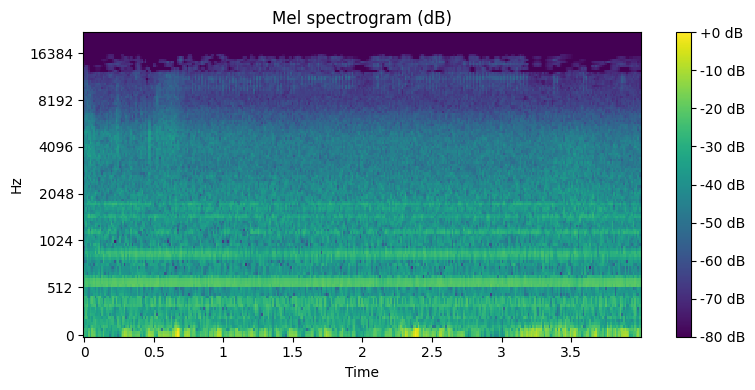

In [68]:
n_fft = 1024
hop_len = 512

# Plot Spectrogram
S_F = extract_features(*example_clip.audio, mode=SPECTROGRAM_METHOD, n_fft=n_fft, hop_length=hop_len)
plot_spectrogram(S_F, example_clip.audio[1], hop_length=hop_len, mode=SPECTROGRAM_METHOD, cmap="viridis")